# Activation Probe Pipeline: Starter Notebook (GPT-2 small)

Part of my TARA capstone. This notebook does three things:

1. Runs GPT-2 small with TransformerLens and caches its internal activations.
2. Turns each sentence into one activation vector per layer.
3. Trains a simple linear probe (logistic regression) at each layer to test whether two groups of sentences can be told apart.

The sentences here are a **harmless toy dataset** (molecular biology vs everyday topics) used only to test that the pipeline works. The real project will swap in benchmark data (see the last section).

In [1]:
# Setup: install TransformerLens
!pip install -q "transformer_lens==2.17.0" "transformers<5"

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

torch.set_grad_enabled(False)  # we only read activations, no training of the model
model = HookedTransformer.from_pretrained("gpt2")
print("Layers:", model.cfg.n_layers, "| Residual stream size:", model.cfg.d_model)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Layers: 12 | Residual stream size: 768


## Step 1: Look inside the model with `run_with_cache`

`run_with_cache` runs the model and saves every internal activation. The **residual stream** after layer *L* (`resid_post`) is the model's running representation of each token at that point.

In [3]:
prompt = "The ribosome translates messenger RNA into protein."
logits, cache = model.run_with_cache(prompt)

tokens = model.to_str_tokens(prompt)
print("Tokens:", tokens)

layer = 6
resid = cache["resid_post", layer]   # shape: [batch, position, d_model]
print("Shape of resid_post at layer", layer, ":", tuple(resid.shape))

Tokens: ['<|endoftext|>', 'The', ' rib', 'os', 'ome', ' translates', ' messenger', ' RNA', ' into', ' protein', '.']
Shape of resid_post at layer 6 : (1, 11, 768)


## Step 2: One vector per sentence per layer

Each sentence has a different number of tokens, so I average over its tokens (skipping the first, start-of-text token) to get one 768-number vector per layer.

In [4]:
def sentence_vectors(texts):
    """Returns an array of shape [n_layers, n_texts, d_model]."""
    out = np.zeros((model.cfg.n_layers, len(texts), model.cfg.d_model))
    for i, text in enumerate(texts):
        _, cache = model.run_with_cache(text)
        for L in range(model.cfg.n_layers):
            out[L, i] = cache["resid_post", L][0, 1:].mean(dim=0).cpu().numpy()
    return out

## Step 3: Toy dataset (harmless placeholder)

Class 1 = molecular biology sentences. Class 0 = everyday sentences. This only checks that the pipeline runs and that a probe can find a topic signal at all.

In [5]:
biology = [
    "DNA polymerase copies each strand during replication.",
    "Enzymes lower the activation energy of a reaction.",
    "Mitochondria produce most of the cell's ATP.",
    "Messenger RNA carries the genetic code to the ribosome.",
    "Proteins fold into shapes that determine their function.",
    "The cell membrane controls what enters and leaves the cell.",
    "Transcription factors switch genes on and off.",
    "Bacteria divide by binary fission.",
    "Antibodies bind to specific antigens.",
    "Chromosomes condense before cell division.",
    "A mutation is a change in the DNA sequence.",
    "PCR makes many copies of a short DNA segment.",
    "Viruses use host cells to make new copies of themselves.",
    "Plasmids are small circular pieces of DNA in bacteria.",
    "Gene expression differs between cell types.",
    "The immune system learns to recognise pathogens.",
    "Codons are three-letter units of the genetic code.",
    "Cell cultures are grown in nutrient media.",
    "Restriction enzymes cut DNA at specific sequences.",
    "Vaccines train the immune system without causing disease.",
]
everyday = [
    "The train was ten minutes late this morning.",
    "She planted tomatoes in the back garden.",
    "The football match ended in a draw.",
    "We ordered pizza for dinner on Friday.",
    "The library closes early on Sundays.",
    "He painted the fence a bright shade of blue.",
    "The beach was crowded during the holidays.",
    "My phone battery runs out by the afternoon.",
    "The cafe on the corner makes great coffee.",
    "They went hiking in the Blue Mountains.",
    "The concert tickets sold out in an hour.",
    "I need to renew my passport next year.",
    "The kids built a sandcastle by the water.",
    "Traffic was heavy on the bridge tonight.",
    "The recipe calls for two cups of flour.",
    "Our team meeting moved to Thursday.",
    "The dog barked at the delivery driver.",
    "It rained all weekend in Sydney.",
    "She finished reading the novel on the plane.",
    "The shop is having a sale on winter jackets.",
]
texts = biology + everyday
labels = np.array([1] * len(biology) + [0] * len(everyday))
X = sentence_vectors(texts)
print("Activation array shape:", X.shape)

Activation array shape: (12, 40, 768)


## Step 4: Train a linear probe at every layer

For each layer, 5-fold cross-validation: train on 80% of sentences, test on the other 20%, five times. Accuracy of 0.5 means guessing; 1.0 means perfect separation.

Layer  0: accuracy = 1.00
Layer  1: accuracy = 1.00
Layer  2: accuracy = 1.00
Layer  3: accuracy = 1.00
Layer  4: accuracy = 1.00
Layer  5: accuracy = 1.00
Layer  6: accuracy = 1.00
Layer  7: accuracy = 1.00
Layer  8: accuracy = 1.00
Layer  9: accuracy = 1.00
Layer 10: accuracy = 1.00
Layer 11: accuracy = 1.00


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


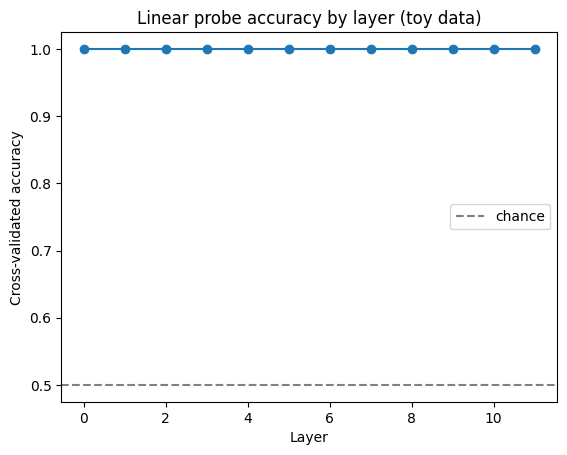

In [6]:
scores = []
for L in range(model.cfg.n_layers):
    probe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    acc = cross_val_score(probe, X[L], labels, cv=5).mean()
    scores.append(acc)
    print(f"Layer {L:2d}: accuracy = {acc:.2f}")

plt.plot(range(model.cfg.n_layers), scores, marker="o")
plt.axhline(0.5, linestyle="--", color="grey", label="chance")
plt.xlabel("Layer"); plt.ylabel("Cross-validated accuracy")
plt.title("Linear probe accuracy by layer (toy data)")
plt.legend(); plt.show()

## What this does and doesn't show

- High accuracy here is **expected**: biology vs everyday topics is an easy split. This is a pipeline test, not a finding.
- The real question is whether a probe can separate hazardous-knowledge *proxy* questions from ordinary biology questions, which are much more alike.

## Next step: swap in benchmark data

Positive class: the biology split of the WMDP benchmark (a published proxy for hazardous knowledge). Negative class: ordinary biology questions from MMLU. Uncomment to try:

```python
# !pip install -q datasets
# from datasets import load_dataset
# pos = load_dataset("cais/wmdp", "wmdp-bio", split="test")["question"][:200]
# neg = load_dataset("cais/mmlu", "college_biology", split="test")["question"][:200]
```

Things to check at that stage: balanced classes, similar question lengths, and a paraphrase test so the probe isn't just learning each dataset's writing style.